In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("Python 版本：", sys.version.split()[0])
print("scikit-learn 版本：", sklearn.__version__)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Python 版本： 3.12.4
scikit-learn 版本： 1.9.0


# 1.认识数据与划分数据
## 1.1 三个最重要的概念

- **特征 `X`**：模型用来判断的输入数据。
- **标签 `y`**：模型需要预测的正确答案。
- **训练集 / 测试集**：
  - 训练集用于学习模型参数。
  - 测试集用于最后检查模型是否能处理未见过的数据。

> 不要用测试集调参数。否则测试结果会变得过于乐观。

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print("样本数：", X.shape[0])
print("特征数：", X.shape[1])
print("类别名称：", list(data.target_names))

display(X.head())
display(y.value_counts())

样本数： 569
特征数： 30
类别名称： [np.str_('malignant'), np.str_('benign')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
1    357
0    212
Name: count, dtype: int64

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("训练集形状：", X_train.shape)
print("测试集形状：", X_test.shape)
print("训练集良性比例：", round(y_train.mean(), 3))
print("测试集良性比例：", round(y_test.mean(), 3))

训练集形状： (455, 30)
测试集形状： (114, 30)
训练集良性比例： 0.626
测试集良性比例： 0.632


### 新手提示

- `test_size=0.20`：20% 数据作为测试集。
- `random_state=42`：固定随机结果，方便复现。
- `stratify=y`：让训练集和测试集保持相似的类别比例。

# 2.用pipeline组织预处理和训练
## 2.1 为什么使用 Pipeline

逻辑回归通常需要先对特征做标准化。

不规范的写法容易发生数据泄露：

1. 先对全部数据计算均值和标准差；
2. 再切分训练集和测试集。

正确做法是把标准化器和模型放进同一个 `Pipeline`。这样标准化器只会在训练数据上学习。

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

pipe
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("训练完成")
print("前 10 个预测结果：", y_pred[:10])

训练完成
前 10 个预测结果： [0 1 0 1 0 1 1 0 0 0]


Pipeline 中每一步都有名字：

- `scaler`：标准化
- `model`：逻辑回归分类器

以后搜索模型参数时，要使用：

```python
model__参数名
```

例如逻辑回归参数 `C` 在 Pipeline 中写成：

```python
model__C
```

In [5]:
print("Pipeline 中的步骤：", pipe.named_steps.keys())
print("当前 C：", pipe.named_steps["model"].C)

Pipeline 中的步骤： dict_keys(['scaler', 'model'])
当前 C： 1.0


# 3.用GridSearchCV搜索超参数
## 3.1 什么是超参数

模型训练前由我们设定的值称为超参数。

逻辑回归中的 `C` 控制正则化强度：

- `C` 较小：约束更强，模型更简单。
- `C` 较大：约束更弱，模型更灵活。

我们不直接猜一个值，而是使用 `GridSearchCV`：

1. 尝试多个参数组合；
2. 对每组参数做交叉验证；
3. 根据指定指标选出较优方案。

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("最优参数：", grid.best_params_)
print("最优交叉验证 F1：", round(grid.best_score_, 4))

最优参数： {'model__C': 0.1, 'model__class_weight': None}
最优交叉验证 F1： 0.9827


### 参数解释

- `param_grid`：需要尝试的参数。
- `scoring="f1"`：使用 F1 选择最优模型。
- `cv=3`：使用 3 折交叉验证。
- `n_jobs=-1`：尽量使用全部 CPU 核心。

In [7]:
results = pd.DataFrame(grid.cv_results_)

display(
    results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_model__C",
            "param_model__class_weight"
        ]
    ]
    .sort_values("rank_test_score")
    .round(4)
)

,rank_test_score,mean_test_score,std_test_score,param_model__C,param_model__class_weight
2,1,0.9827,0.0049,0.10,NaN
4,2,0.9808,0.0023,1.00,NaN
3,3,0.9771,0.0067,0.10,balanced
5,4,0.9770,0.0067,1.00,balanced
1,5,0.9738,0.0127,0.01,balanced
7,6,0.9737,0.0086,10.00,balanced
6,7,0.9703,0.0090,10.00,NaN
0,8,0.9629,0.0061,0.01,NaN


阅读结果时重点看：

- `mean_test_score`：平均交叉验证 F1。
- `std_test_score`：不同折之间的波动。
- `rank_test_score`：排名，1 表示最好。

不要只记住最优参数，还要观察不同参数之间的差距是否明显。

# 4.在测试集上评估最优模型
`GridSearchCV` 完成后，`best_estimator_` 已经保存了最优 Pipeline。

现在才使用测试集进行最终评估。

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

best_model = grid.best_estimator_

test_pred = best_model.predict(X_test)

metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred),
    "Recall": recall_score(y_test, test_pred),
    "F1": f1_score(y_test, test_pred)
})

display(metrics.round(4))

Accuracy     0.9737
Precision    0.9726
Recall       0.9861
F1           0.9793
dtype: float64

In [9]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=data.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 4.1 如何理解四个指标

- **Accuracy**：所有样本中，预测正确的比例。
- **Precision**：预测为某类的样本中，真正属于该类的比例。
- **Recall**：真正属于某类的样本中，被模型找出的比例。
- **F1**：Precision 和 Recall 的综合指标。

在实际安全或医疗任务中，不能只看 Accuracy。还要根据漏检和误检的代价关注 Recall 或 Precision。

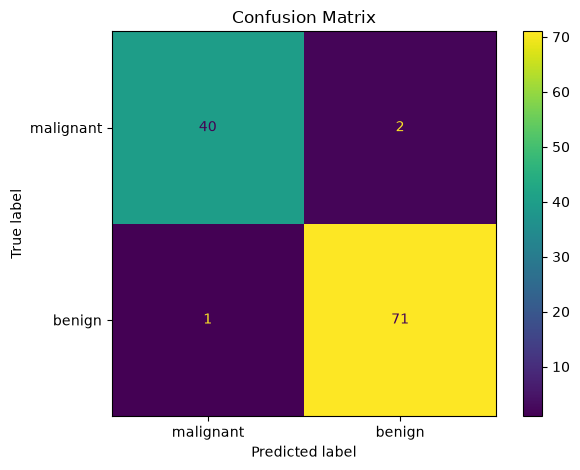

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=data.target_names
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 4.2 混淆矩阵怎么看

- 对角线：预测正确的数量。
- 非对角线：预测错误的数量。

观察问题：

1. 哪个类别更容易被预测错误？
2. 模型更容易漏掉恶性样本，还是把良性样本误判为恶性？
3. 在医疗场景中，哪一种错误通常更危险？

# 5.用pytorch autogrd查看梯度
## 5.1 最简单的反向传播

定义：

\[
z=x^2+2xy+y^3
\]

理论梯度：

\[
\frac{\partial z}{\partial x}=2x+2y
\]

\[
\frac{\partial z}{\partial y}=2x+3y^2
\]

当 `x=2，y=3` 时：

- `dz/dx = 10`
- `dz/dy = 31`

In [11]:
try:
    import torch
    print("PyTorch 版本：", torch.__version__)
except ImportError:
    torch = None
    print("未安装 PyTorch，请先运行：pip install torch")

PyTorch 版本： 2.13.0+cpu


In [12]:
if torch is not None:
    x = torch.tensor(2.0, requires_grad=True)
    y_torch = torch.tensor(3.0, requires_grad=True)

    z = x**2 + 2 * x * y_torch + y_torch**3

    z.backward()

    print("z =", z.item())
    print("x 的梯度 =", x.grad.item())
    print("y 的梯度 =", y_torch.grad.item())

z = 43.0
x 的梯度 = 10.0
y 的梯度 = 31.0


### 关键理解

- `requires_grad=True`：告诉 PyTorch 需要跟踪这个变量的运算。
- `z.backward()`：从结果反向计算每个变量的梯度。
- `x.grad`：保存 `z` 对 `x` 的偏导数。
- `y.grad`：保存 `z` 对 `y` 的偏导数。

## 5.2 观察梯度累积

In [13]:
if torch is not None:
    a = torch.tensor(2.0, requires_grad=True)

    loss1 = a**2
    loss1.backward()
    print("第一次 backward 后：", a.grad.item())

    loss2 = 3 * a
    loss2.backward()
    print("未清零，再次 backward 后：", a.grad.item())

    a.grad.zero_()

    loss3 = 3 * a
    loss3.backward()
    print("清零后，再次 backward：", a.grad.item())

第一次 backward 后： 4.0
未清零，再次 backward 后： 7.0
清零后，再次 backward： 3.0


PyTorch 默认会累积梯度。

训练神经网络时，每个批次开始前通常要执行：

```python
optimizer.zero_grad()
```

否则当前批次的梯度会和之前批次的梯度相加。

# 6.练习
## 练习 1：修改 Pipeline 参数

把参数网格改成：

```python
"model__C": [0.1, 1, 10, 100]
```

重新运行 GridSearchCV，记录：

- 最优参数
- 最优交叉验证 F1
- 测试集 F1

---

## 练习 2：改用 Recall 调参

把：

```python
scoring="f1"
```

改成：

```python
scoring="recall"
```

比较新的最优参数和混淆矩阵。

思考：为什么优化目标改变后，最优模型可能改变？

---

## 练习 3：修改 autograd 函数

使用：

\[
f(x)=x^3+2x^2-5x+1
\]

令 `x=2`，用 autograd 计算梯度，再手算验证。

提示：

\[
f'(x)=3x^2+4x-5
\]

In [14]:
if torch is not None:
    x_exercise = torch.tensor(2.0, requires_grad=True)

    # TODO：定义 f
    f = x_exercise**3 + 2*x_exercise**2 - 5*x_exercise + 1

    f.backward()

    print("autograd 梯度：", x_exercise.grad.item())
    print("理论梯度：", 3*(2**2) + 4*2 - 5)

autograd 梯度： 15.0
理论梯度： 15
